# MNIST Model Comparison

Goal: Compare Perceptron, Artificial Neural Networks (ANN), and Convolutional Neural Networks (CNN) on the MNIST handwritten digit dataset.

## Import 

In [10]:
import pandas as pd
import numpy as np
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score


## Load Model

In [ ]:
perceptron_rs = joblib.load(r"C:\Users\ngarg\OneDrive\Desktop\GitHub\ml-projects\mnist-model-comparison\Perceptron\perceptron_rs.pkl")

perceptron_model = perceptron_rs.best_estimator_

ann_model = load_model(r"C:\Users\ngarg\OneDrive\Desktop\GitHub\ml-projects\mnist-model-comparison\ANN\ann_model.h5")
cnn_model = load_model(r"C:\Users\ngarg\OneDrive\Desktop\GitHub\ml-projects\mnist-model-comparison\CNN\cnn_model.h5")

X_test = joblib.load(r"C:\Users\ngarg\OneDrive\Desktop\GitHub\ml-projects\mnist-model-comparison\dataset\X_test.pkl")
y_test = joblib.load(r"C:\Users\ngarg\OneDrive\Desktop\GitHub\ml-projects\mnist-model-comparison\dataset\y_test.pkl")
X_train = joblib.load(r"C:\Users\ngarg\OneDrive\Desktop\GitHub\ml-projects\mnist-model-comparison\dataset\X_train.pkl")
y_train = joblib.load
(r"C:\Users\ngarg\OneDrive\Desktop\GitHub\ml-projects\mnist-model-comparison\dataset\y_train.pkl")

'C:\\Users\\ngarg\\OneDrive\\Desktop\\GitHub\\ml-projects\\mnist-model-comparison\\dataset\\y_train.pkl'

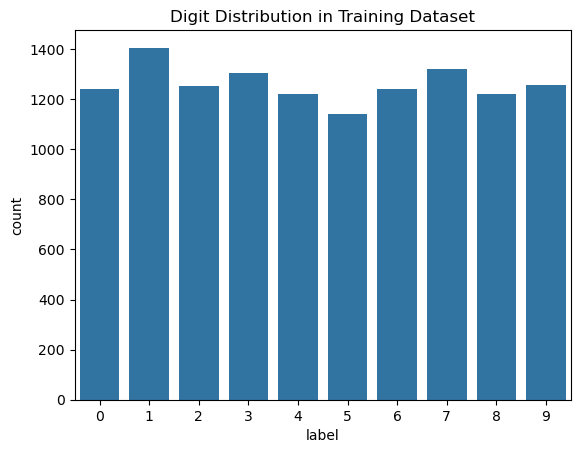

In [20]:
sns.countplot(x=y_test)
plt.title("Digit Distribution in Training Dataset")
plt.show()

In [ ]:
y_pred_p = perceptron_model.predict(X_test)

y_pred_ann = np.argmax(
    ann_model.predict(X_test),
    axis=1
)

394/394 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [23]:
X_test_cnn = X_test.to_numpy().reshape(-1, 28, 28, 1)
y_pred_cnn = np.argmax(
    cnn_model.predict(X_test_cnn),
    axis=1
)

394/394 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


## Accuracy Comparison
This section compares the classification accuracy of the Perceptron, ANN, and CNN models on the MNIST test dataset.

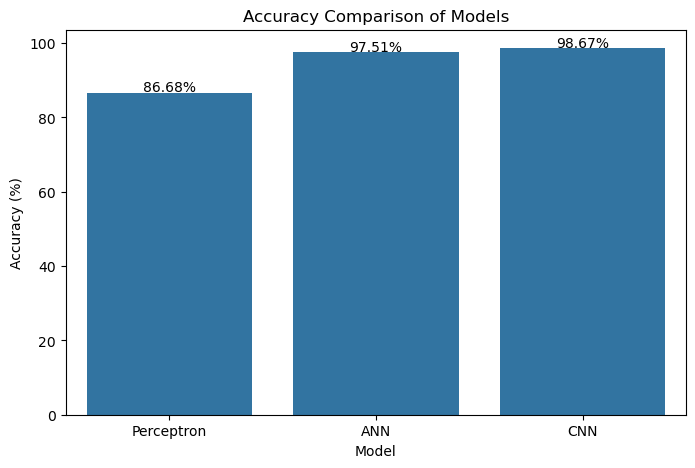

In [39]:
acc_p = accuracy_score(y_test, y_pred_p)
acc_ann = accuracy_score(y_test, y_pred_ann)
acc_cnn = accuracy_score(y_test, y_pred_cnn)

accuracy_df = pd.DataFrame({
    "Model": ["Perceptron", "ANN", "CNN"],
    "Accuracy (%)": [
        acc_p * 100,
        acc_ann * 100,
        acc_cnn * 100
    ]
})


plt.figure(figsize=(8,5))

sns.barplot(
    data=accuracy_df,
    x="Model",
    y="Accuracy (%)"
)

plt.title("Accuracy Comparison of Models")
plt.ylabel("Accuracy (%)")

for i, value in enumerate(accuracy_df["Accuracy (%)"]):
    plt.text(i, value + 0.2, f"{value:.2f}%" , ha = 'center')

plt.show()

## Error Rate Comparison
Error rate represents the percentage of test samples that were classified incorrectly by each model.

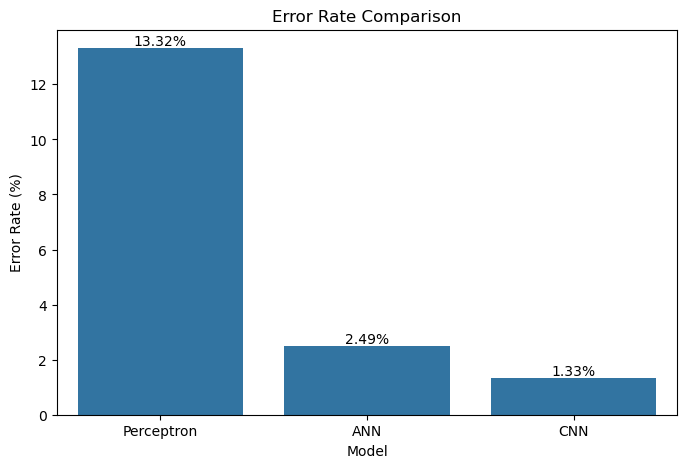

In [38]:
error_df = accuracy_df.copy()
error_df["Error Rate (%)"] = 100 - error_df["Accuracy (%)"]

plt.figure(figsize=(8,5))

sns.barplot(
    data=error_df,
    x="Model",
    y="Error Rate (%)"
)

plt.title("Error Rate Comparison")
plt.ylabel("Error Rate (%)")

for i, value in enumerate(error_df["Error Rate (%)"]):
    plt.text(i, value + 0.1, f"{value:.2f}%" , ha = 'center')

plt.show()

## Classification Report Comparision

In [40]:
from sklearn.metrics import classification_report

report_p = classification_report(y_test, y_pred_p, output_dict=True)
report_ann = classification_report(y_test, y_pred_ann, output_dict=True)
report_cnn = classification_report(y_test, y_pred_cnn, output_dict=True)

In [41]:
metrics_df = pd.DataFrame({
    "Model": ["Perceptron", "ANN", "CNN"],
    
    "Precision": [
        report_p["weighted avg"]["precision"],
        report_ann["weighted avg"]["precision"],
        report_cnn["weighted avg"]["precision"]
    ],
    
    "Recall": [
        report_p["weighted avg"]["recall"],
        report_ann["weighted avg"]["recall"],
        report_cnn["weighted avg"]["recall"]
    ],
    
    "F1-Score": [
        report_p["weighted avg"]["f1-score"],
        report_ann["weighted avg"]["f1-score"],
        report_cnn["weighted avg"]["f1-score"]
    ]
})

metrics_df

,Model,Precision,Recall,F1-Score
0,Perceptron,0.873236,0.866825,0.865188
1,ANN,0.975109,0.975079,0.975051
2,CNN,0.986688,0.986667,0.986663


In [42]:
metrics_melted = metrics_df.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

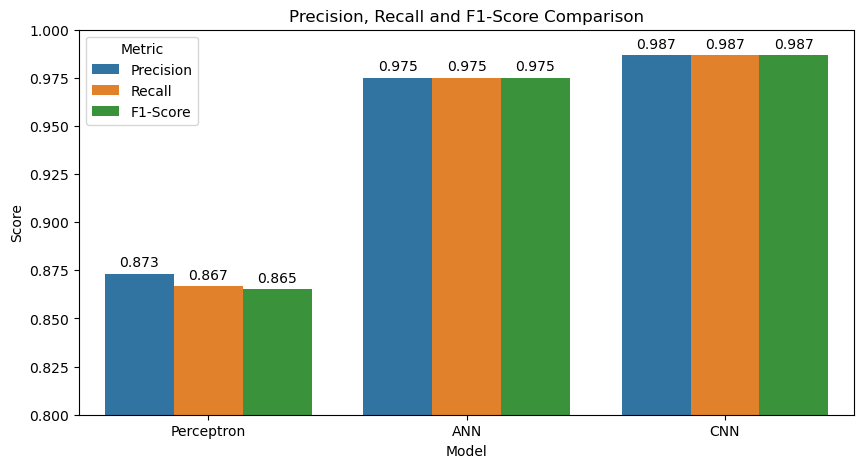

In [44]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=metrics_melted,
    x="Model",
    y="Score",
    hue="Metric"
)

for container in plt.gca().containers:
    plt.bar_label(
        container,
        fmt="%.3f",
        padding=3
    )
    
plt.title("Precision, Recall and F1-Score Comparison")

plt.ylim(0.8, 1.0)

plt.show()

## Correct vs Incorrect Predictions Comparison

In [55]:
total = y_test.shape

In [90]:
wrong_p = np.sum(y_pred_p != y_test)
wrong_ann = np.sum(y_pred_ann != y_test)
wrong_cnn = np.sum(y_pred_cnn != y_test)

correct_p = total - wrong_p
correct_ann = total - wrong_ann
correct_cnn = total - wrong_cnn

In [91]:
comparison_df = pd.DataFrame({
    "Model": ["Perceptron", "ANN", "CNN"],
    "Correct": [correct_p, correct_ann, correct_cnn],
    "Incorrect": [wrong_p, wrong_ann, wrong_cnn]
})

comparison_df['Correct'] = comparison_df['Correct'].astype(np.int64)
comparison_df

,Model,Correct,Incorrect
0,Perceptron,10922,1678
1,ANN,12286,314
2,CNN,12432,168


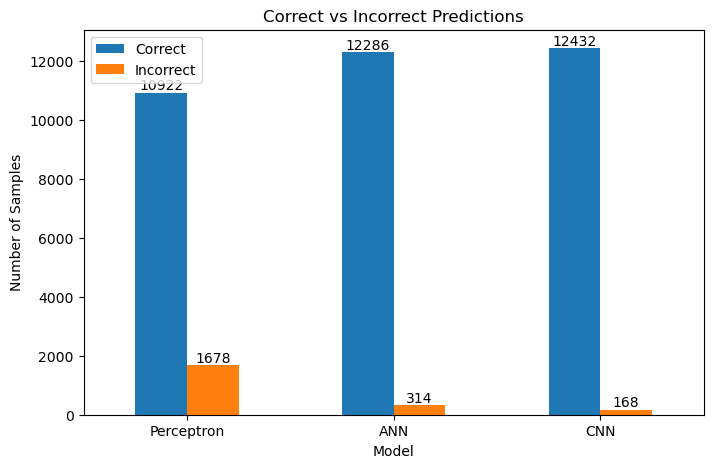

In [92]:
ax = comparison_df.set_index("Model").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Correct vs Incorrect Predictions")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container)

plt.show()

## Confusion Matrix Comparison
Confusion matrices provide a detailed view of model performance by showing the number of correct and incorrect predictions for each digit class.

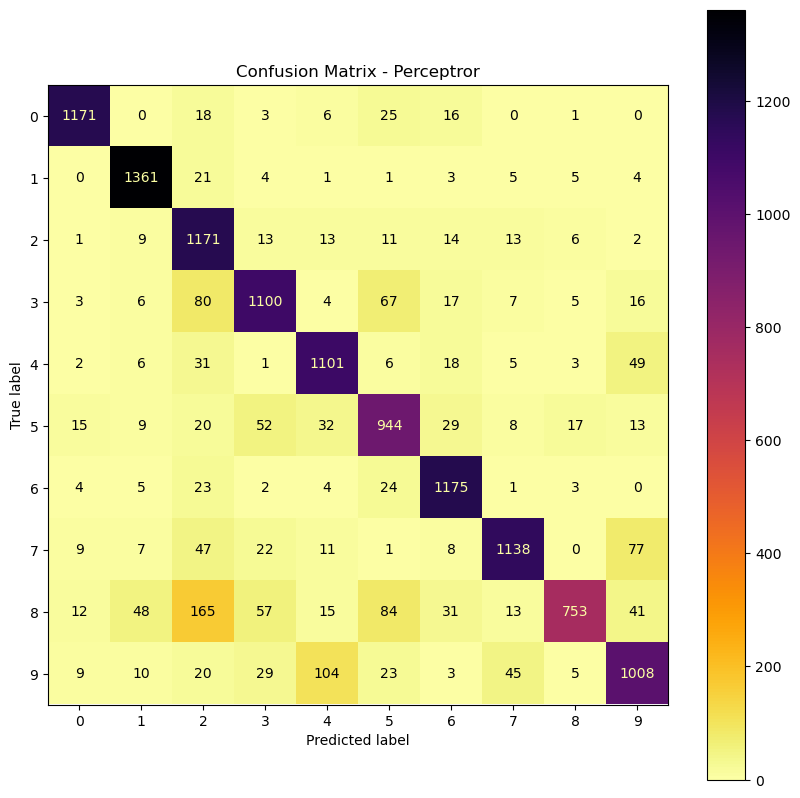

In [93]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(10,10))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_p,
    cmap="inferno_r",
    values_format= 'd',
    ax=ax
)

plt.title("Confusion Matrix - Perceptror")
plt.show()

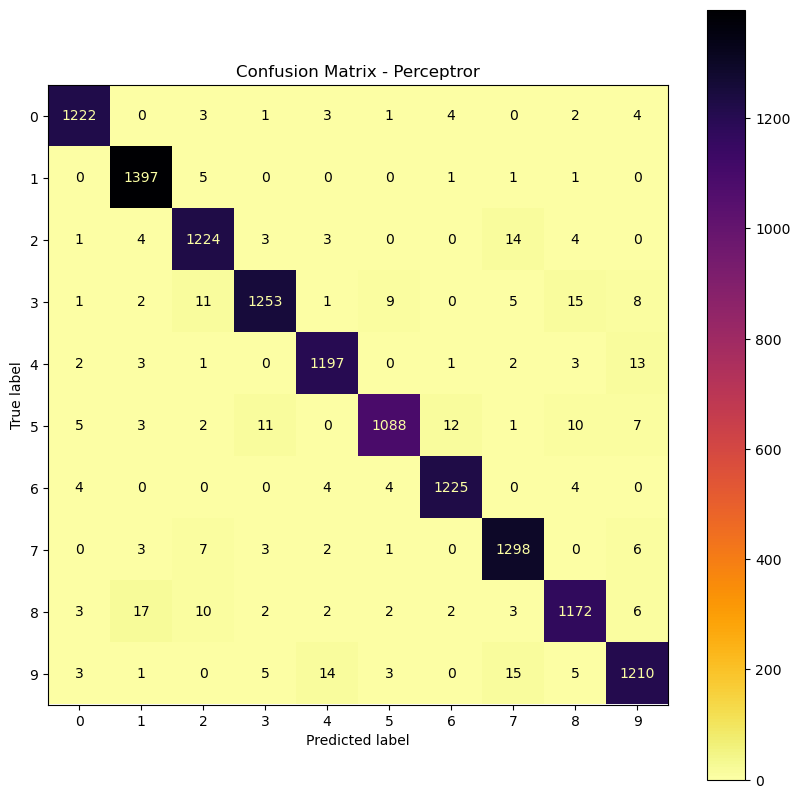

In [94]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(10,10))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_ann,
    cmap="inferno_r",
    values_format= 'd',
    ax=ax
)

plt.title("Confusion Matrix - Perceptror")
plt.show()

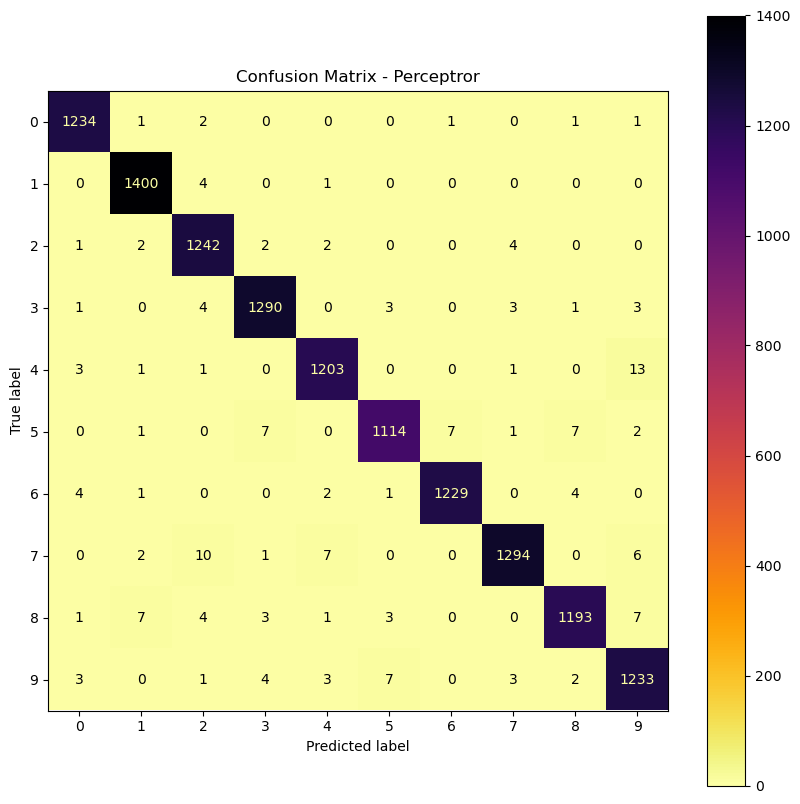

In [95]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(10,10))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_cnn,
    cmap="inferno_r",
    values_format= 'd',
    ax=ax
)

plt.title("Confusion Matrix - Perceptror")
plt.show()

## CNN ERROR ANALYSIS
Although the CNN achieved the highest accuracy, a small number of digits were still misclassified. This section analyzes some of these incorrect predictions.

In [96]:
wrong_idx = np.where(y_pred_cnn != y_test)[0]

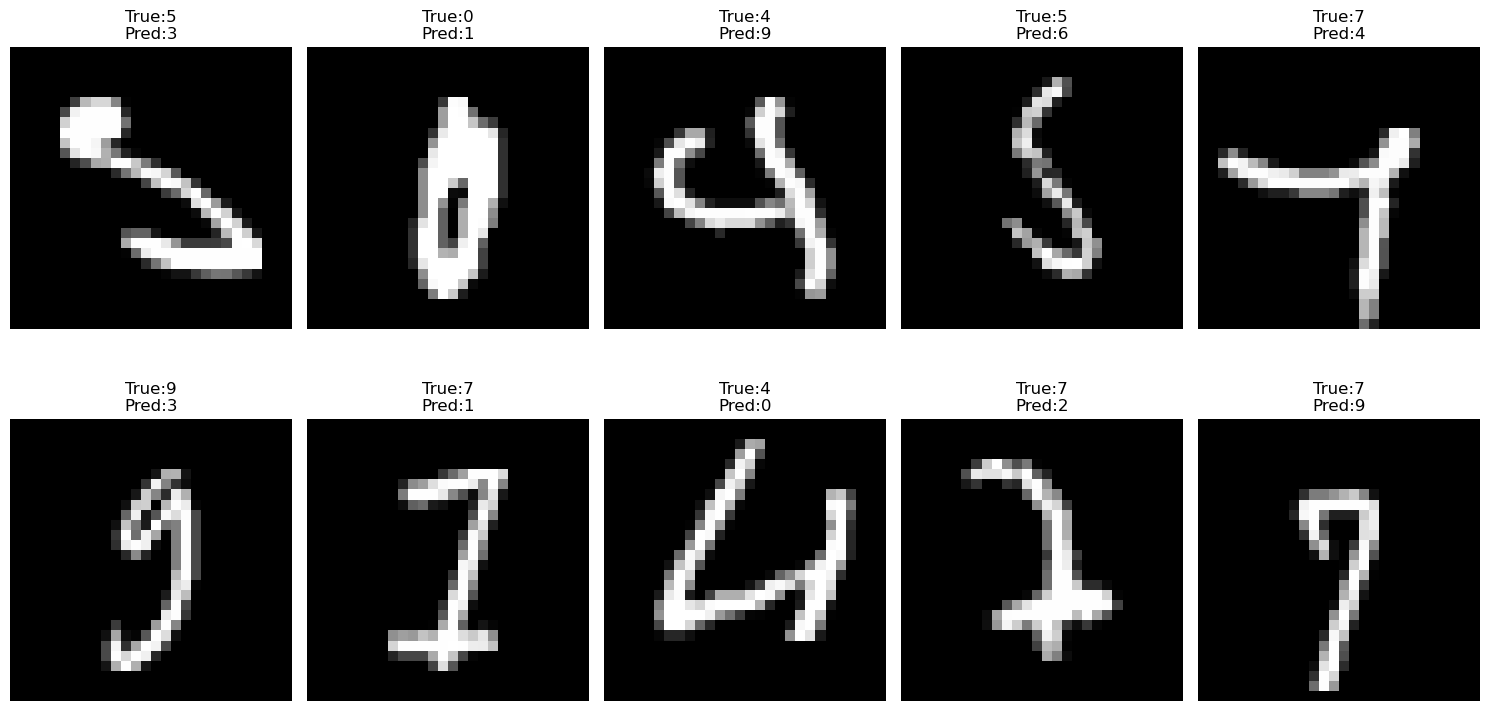

In [97]:
plt.figure(figsize=(15,8))

for i, idx in enumerate(wrong_idx[:10]):
    plt.subplot(2,5,i+1)

    plt.imshow( X_test_cnn[idx].reshape(28,28) , cmap="gray" )

    plt.title( f"True:{y_test.iloc[idx]}\nPred:{y_pred_cnn[idx]}" )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [98]:
y_prob_cnn = cnn_model.predict(X_test_cnn)

 11/394 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step  

394/394 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [99]:
wrong_idx = np.where(y_pred_cnn != y_test)[0]

for idx in wrong_idx[:10]:

    confidence = np.max(y_prob_cnn[idx]) * 100

    print(
        f"True: {y_test.iloc[idx]}, "
        f"Pred: {y_pred_cnn[idx]}, "
        f"Confidence: {confidence:.4f}"
    )

True: 5, Pred: 3, Confidence: 80.9643
True: 0, Pred: 1, Confidence: 55.9318
True: 4, Pred: 9, Confidence: 88.7087
True: 5, Pred: 6, Confidence: 64.1235
True: 7, Pred: 4, Confidence: 60.1727
True: 9, Pred: 3, Confidence: 68.4837
True: 7, Pred: 1, Confidence: 48.5788
True: 4, Pred: 0, Confidence: 49.0205
True: 7, Pred: 2, Confidence: 99.8219
True: 7, Pred: 9, Confidence: 90.0341


## Final Comparison Table

In [100]:
final_df = pd.DataFrame({
    "Metric": [
        "Accuracy (%)",
        "Precision (%)",
        "Recall (%)",
        "F1-Score (%)",
        "Misclassified Samples"
    ],

    "Perceptron": [
        acc_p * 100,
        report_p["weighted avg"]["precision"] * 100,
        report_p["weighted avg"]["recall"] * 100,
        report_p["weighted avg"]["f1-score"] * 100,
        wrong_p
    ],

    "ANN": [
        acc_ann * 100,
        report_ann["weighted avg"]["precision"] * 100,
        report_ann["weighted avg"]["recall"] * 100,
        report_ann["weighted avg"]["f1-score"] * 100,
        wrong_ann
    ],

    "CNN": [
        acc_cnn * 100,
        report_cnn["weighted avg"]["precision"] * 100,
        report_cnn["weighted avg"]["recall"] * 100,
        report_cnn["weighted avg"]["f1-score"] * 100,
        wrong_cnn
    ]
})

final_df = final_df.round(2)

In [101]:
final_df

,Metric,Perceptron,ANN,CNN
0,Accuracy (%),86.68,97.51,98.67
1,Precision (%),87.32,97.51,98.67
2,Recall (%),86.68,97.51,98.67
3,F1-Score (%),86.52,97.51,98.67
4,Misclassified Samples,1678.00,314.00,168.00


The CNN achieved the best overall performance across all evaluation metrics, including Accuracy, Precision, Recall, and F1-Score. It also produced the lowest number of misclassified samples. The ANN delivered strong performance and significantly outperformed the Perceptron, while the Perceptron served as a simple baseline model with the lowest classification capability.